Este código deja el pipeline bien modular (funciones reutilizables por año), centraliza el cálculo de outliers y la eliminación de variables correlacionadas, y define dos configuraciones de hiperparámetros por cada tipo de modelo (Random Forest y Gradient Boosting + Red Neuronal Dropout), entrenando con 2025 y evaluando con 2026

El flujo de trabajo que se plantea es:

1. Carga de datos: Leer los CSV de 2025 y 2026.
2. Ingeniería de variables básica: Calculo de métricas del calendario, etc. (función construir_dataset_anual).
3. Ingeniería Geoespacial Avanzada (OSMnx):Conexión con OpenStreetMap, añadiendo nuevas columnas (ocio_500m, transporte_500m, distancia_ciutat_artes_m) a las tablas df_features_25 y df_features_26.
4. Limpieza final (Fuga de datos y Outliers): Se eliminan los pisos de más de 40.000€ del entrenamiento (para no engañar al modelo) y se borran las variables prohibidas (para evitar fugas de información). Se crea así X_train y X_test definitivos.
5. Preprocesado (ColumnTransformer): Escalado de variables numericas y transformación a ceros y unos de variables categóricas (como el tipo de habitación).
6. Entrenamiento: Estudio del modelo. Los algoritmos analizan el X_train (enriquecido con información de bares, metros y monumentos).
7. Evaluación: Medición del RMSE y analisis de la importancia de variables.

**1. Carga de de datos**

Este script está diseñado para detectar automáticamente si disponemos de los datos completos (carpeta data/) o si estamos ejecutando la versión de demostración de GitHub (carpeta data_sample/). Los datos se estructurarán en un diccionario llamado db.

In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

# 1. En Jupyter usamos Path.cwd() (Current Working Directory) en lugar de __file__
DIRECTORIO_ACTUAL = Path.cwd()

# Si se guarda el notebook dentro de la carpeta 'src/', se sube un nivel, si se guarda en la carpeta raíz, se mantiene.
if DIRECTORIO_ACTUAL.name == "src":
    DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
else:
    DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL

# 2. Detección de los datos reales o se usan la muestra de GitHub
if (DIRECTORIO_RAIZ / "data").exists():
    DIRECTORIO_DATOS = DIRECTORIO_RAIZ / "data"
    print("🟢 Usando carpeta de datos REALES (data/)")
else:
    DIRECTORIO_DATOS = DIRECTORIO_RAIZ / "data_sample"
    print("🟡 Usando carpeta de datos de MUESTRA descargada de GitHub (data_sample/)")

def cargar_datos_año(año):
    """Carga los 5 archivos de un año específico."""
    ruta_año = DIRECTORIO_DATOS / str(año)
    print(f"Cargando datos del año {año}...")
    
    return {
        "listings": pd.read_csv(ruta_año / "listings.csv", low_memory=False),
        "reviews": pd.read_csv(ruta_año / "reviews.csv", low_memory=False),
        "calendar": pd.read_csv(ruta_año / "calendar.csv.gz", compression='gzip', low_memory=False),
        "neigh": pd.read_csv(ruta_año / "neighbourhoods.csv"),
        "mapa_barrios": gpd.read_file(ruta_año / "neighbourhoods.geojson")
    }

# 3. Cargar los datos
db = {}
for año in [2025, 2026]:
    if (DIRECTORIO_DATOS / str(año)).exists():
        db[str(año)] = cargar_datos_año(año)

# Ejemplo de uso en la siguiente celda:
df_listings = db["2025"]["listings"]
df_listings.head()

🟢 Usando carpeta de datos REALES (data/)
Cargando datos del año 2025...
Cargando datos del año 2026...


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,48154,Precioso apartamento con wifi,219476,Antonio,LA SAIDIA,MORVEDRE,39.48375,-0.37502,Entire home/apt,83.0,3,197,2025-09-15,1.08,4,150,26,VT-41540-V
1,137143,PENTHOUSE ON FRONT LINE BEACH,670775,Maria De La Piedad,POBLATS DEL SUD,EL SALER,39.36335,-0.31932,Entire home/apt,390.0,10,1,2013-07-02,0.01,5,20,0,VT32745V
2,149715,1900 Style Valencian Beach Home for 10px,5947,Susana Barbara,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.46746,-0.32813,Entire home/apt,245.0,2,313,2025-09-15,1.81,1,287,41,ESFCTU000046025000580569000000000000000000VT-3...
3,165971,★ Architectural touch! ★,791187,Inés,EXTRAMURS,LA ROQUETA,39.46790,-0.38206,Entire home/apt,124.0,5,576,2025-09-03,3.34,8,106,46,VT-32757-V
4,182221,Apartments Calatrava City Valencia,1315567,Chiara,CAMINS AL GRAU,AIORA,39.46343,-0.34325,Entire home/apt,137.0,3,9,2025-03-17,0.07,1,176,1,VT-38755-V


2.a Extracción de variables para el EDA de 2025

    DataFrames del diccionario para trabajar de forma más cómoda con las tablas del año 2025.

In [2]:
df_listings_25 = db["2025"]["listings"]
df_reviews_25  = db["2025"]["reviews"]
df_calendar_25 = db["2025"]["calendar"]
df_neigh_25    = db["2025"]["neigh"]
mapa_25        = db["2025"]["mapa_barrios"]

print("Tablas listas para el análisis.")

Tablas listas para el análisis.


2.b Extracción de variables para el EDA de 2026

    DataFrames del diccionario para trabajar de forma más cómoda con las tablas del año 2026.

In [3]:
df_listings_26 = db["2026"]["listings"]
df_reviews_26  = db["2026"]["reviews"]
df_calendar_26 = db["2026"]["calendar"]
df_neigh_26    = db["2026"]["neigh"]
mapa_26        = db["2026"]["mapa_barrios"]

print("Tablas listas para el análisis.")

Tablas listas para el análisis.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7844 entries, 0 to 7843
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              7844 non-null   int64  
 1   name                            7844 non-null   object 
 2   host_id                         7844 non-null   int64  
 3   host_name                       7838 non-null   object 
 4   neighbourhood_group             7844 non-null   object 
 5   neighbourhood                   7844 non-null   object 
 6   latitude                        7844 non-null   float64
 7   longitude                       7844 non-null   float64
 8   room_type                       7844 non-null   object 
 9   price                           6979 non-null   float64
 10  minimum_nights                  7844 non-null   int64  
 11  number_of_reviews               7844 non-null   int64  
 12  last_review                     68

<Axes: >

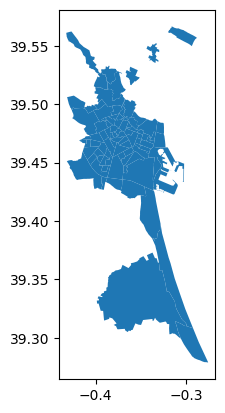

In [4]:
# Ver la información básica y valores nulos
df_listings_25.info()

# Ver estadísticas descriptivas básicas
df_listings_25.describe()

# Pintar el mapa de barrios rápidamente (si estás en Jupyter, se dibujará debajo de la celda)
mapa_25.plot()

In [5]:
# ============================================
# 1. Importación de librerías adicionales
# ============================================

import numpy as np
from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

**2. Funciones auxiliares para análisis de outliers y selección de variables**

In [6]:
def resumen_outliers_iqr(df, columnas_numericas, nombre_df="df"):
    """
    Calcula el resumen de outliers por IQR para un conjunto de columnas numéricas.
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame sobre el que se calculan los outliers.
    columnas_numericas : list of str
        Nombres de las columnas numéricas a analizar.
    nombre_df : str
        Nombre lógico del dataframe (para identificar en prints/logs).
    
    Returns
    -------
    pd.DataFrame
        Tabla con Q1, Q3, IQR, límites inferior/superior y número/porcentaje de outliers.
    """
    resultados = []

    for col in columnas_numericas:
        serie = df[col].dropna()
        if serie.empty:
            continue

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
        n_outliers = len(outliers)
        pct_outliers = n_outliers / len(serie) * 100

        resultados.append({
            "dataframe": nombre_df,
            "columna": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "n_outliers": n_outliers,
            "pct_outliers": pct_outliers
        })

    return pd.DataFrame(resultados)


def eliminar_variables_correlacionadas(df, columnas_numericas, umbral=0.9):
    """
    Identifica y elimina variables numéricas altamente correlacionadas.
    
    Estrategia:
    - Se calcula la matriz de correlaciones absolutas.
    - Para cada par con correlación > umbral, se elimina una de las dos columnas.
      Aquí se mantiene la primera columna y se elimina la siguiente.
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada (no se modifica in-place).
    columnas_numericas : list of str
        Lista de columnas numéricas a considerar.
    umbral : float
        Umbral de correlación absoluta por encima del cual se elimina una variable.
        
    Returns
    -------
    df_filtrado : pd.DataFrame
        Copia del dataframe sin las columnas altamente correlacionadas.
    columnas_eliminadas : list of str
        Lista de nombres de columnas que se han eliminado.
    """
    df_num = df[columnas_numericas].copy()
    corr_matrix = df_num.corr().abs()

    # Triángulo superior de la matriz de correlación
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    columnas_eliminar = [
        column for column in upper.columns 
        if any(upper[column] > umbral)
    ]

    df_filtrado = df.drop(columns=columnas_eliminar, errors="ignore")

    return df_filtrado, columnas_eliminar

**3.1. Funciones de feature engineering para un año (pipeline reutilizable unificado)**

In [7]:
import osmnx as ox
from shapely.geometry import Point

# Configurar OSMnx para usar caché y evitar descargas repetidas
ox.settings.use_cache = True
ox.settings.log_console = True

# Coordenadas de referencia (Latitud, Longitud)
VALENCIA_CENTER = (39.4702, -0.3768)  
VALENCIA_BEACH = (39.4680, -0.3200)   
CIUTAT_ARTES = (39.4542, -0.3503)

def preparar_listings(df_listings, df_neigh):
    """Limpia y enriquece la tabla de anuncios con el CSV de barrios."""
    df = df_listings.copy()
    if "neighbourhood_group" not in df.columns and "neighbourhood_group" in df_neigh.columns:
        df = df.merge(
            df_neigh[["neighbourhood", "neighbourhood_group"]],
            on="neighbourhood",
            how="left",
            suffixes=("", "_neigh")
        )
    return df

def agregar_calendar_por_listing(df_calendar):
    """Agrega la tabla de calendar por listing_id para obtener métricas anuales."""
    df = df_calendar.copy()
    if not np.issubdtype(df["date"].dtype, np.datetime64):
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    
    df["year"] = df["date"].dt.year
    if "listing_id" not in df.columns and "id" in df.columns:
        df = df.rename(columns={"id": "listing_id"})

    df["available_flag"] = df["available"].map({"t": 1, "f": 0})
    df["booked_flag"] = 1 - df["available_flag"]

    if "price" in df.columns:
        if df["price"].dtype == object:
            df["price"] = df["price"].astype(str).str.replace(r"[^0-9\.\-]", "", regex=True).replace("", np.nan).astype(float)
        df["revenue_day"] = df["price"] * df["booked_flag"]
        agregaciones = df.groupby(["listing_id", "year"]).agg(
            availability_365=("available_flag", "sum"),
            total_booked_days=("booked_flag", "sum"),
            avg_daily_price_year=("price", "mean"),
            total_revenue_year=("revenue_day", "sum"),
        ).reset_index()
    else:
        print("Aviso: No se encontró 'price' en el calendar. Omitiendo cálculo de ingresos.")
        agregaciones = df.groupby(["listing_id", "year"]).agg(
            availability_365=("available_flag", "sum"),
            total_booked_days=("booked_flag", "sum")
        ).reset_index()
        agregaciones["avg_daily_price_year"] = np.nan
        agregaciones["total_revenue_year"] = np.nan

    total_dias = agregaciones["availability_365"] + agregaciones["total_booked_days"]
    agregaciones["occupancy_rate_year"] = np.where(total_dias > 0, agregaciones["total_booked_days"] / total_dias, 0)
    return agregaciones


def enriquecimiento_geoespacial_total(df, ciudad="Valencia, Spain"):
    """
    Sustituye a la antigua función Haversine.
    Usa GeoPandas y proyecciones UTM para distancias exactas y extrae POIs de OSM.
    """
    print(f"🌍 Iniciando enriquecimiento geoespacial para {len(df)} alojamientos...")
    df_geo = df.copy()
    
    # 1. Convertir a GeoDataFrame y proyectar a UTM Zona 30N (EPSG:25830)
    geometria = [Point(xy) for xy in zip(df_geo['longitude'], df_geo['latitude'])]
    gdf_airbnb = gpd.GeoDataFrame(df_geo, geometry=geometria, crs="EPSG:4326")
    gdf_airbnb = gdf_airbnb.to_crs(epsg=25830)
    
    # 2. Convertir puntos de referencia a UTM (Nota: Point recibe Longitud, Latitud)
    puntos_referencia = gpd.GeoSeries([
        Point(VALENCIA_CENTER[1], VALENCIA_CENTER[0]),
        Point(VALENCIA_BEACH[1], VALENCIA_BEACH[0]),
        Point(CIUTAT_ARTES[1], CIUTAT_ARTES[0])
    ], crs="EPSG:4326").to_crs(epsg=25830)
    
    # 3. Distancias exactas (en metros) de forma vectorizada (¡Sustituye a Haversine!)
    print("   -> Calculando distancias al Centro, Playa y Ciudad de las Artes...")
    df_geo["dist_to_center_m"] = gdf_airbnb.geometry.distance(puntos_referencia.iloc[0])
    df_geo["dist_to_beach_m"] = gdf_airbnb.geometry.distance(puntos_referencia.iloc[1])
    df_geo["dist_to_arts_m"] = gdf_airbnb.geometry.distance(puntos_referencia.iloc[2])
    
    # 4. OSMnx: Descargar Ocio y Transporte
    print("   -> Descargando datos de Ocio y Transporte de OpenStreetMap...")
    gdf_ocio = ox.features_from_place(ciudad, {"amenity": ["restaurant", "cafe", "bar", "pub"]})
    gdf_ocio['geometry'] = gdf_ocio.geometry.centroid
    gdf_ocio = gdf_ocio.to_crs(epsg=25830)
    
    gdf_transporte = ox.features_from_place(ciudad, {"railway": ["station", "subway_entrance"]})
    gdf_transporte['geometry'] = gdf_transporte.geometry.centroid
    gdf_transporte = gdf_transporte.to_crs(epsg=25830)

    # 5. Cruce espacial (buffer 500m)
    print("   -> Calculando densidad de servicios (radio 500m)...")
    gdf_airbnb_buffer = gdf_airbnb.copy()
    gdf_airbnb_buffer.geometry = gdf_airbnb_buffer.geometry.buffer(500)
    
    cruce_ocio = gpd.sjoin(gdf_ocio, gdf_airbnb_buffer, how="inner", predicate="within")
    cruce_transporte = gpd.sjoin(gdf_transporte, gdf_airbnb_buffer, how="inner", predicate="within")
    
    df_geo['ocio_500m'] = df_geo.index.map(cruce_ocio.groupby('index_right').size()).fillna(0)
    df_geo['transporte_500m'] = df_geo.index.map(cruce_transporte.groupby('index_right').size()).fillna(0)

    print("✅ ¡Enriquecimiento geoespacial completado!")
    return df_geo


def construir_dataset_anual(df_listings, df_calendar, df_neigh, mapa_barrios, year_label, df_imagenes=None):
    """
    Construye el dataset de features a nivel de anuncio para un año concreto, 
    integrando calendario, variables geoespaciales y visión artificial.
    """
    
    # 1. Preparar listings y calendar base
    df_limpio = preparar_listings(df_listings, df_neigh)
    df_cal_agregado = agregar_calendar_por_listing(df_calendar)
    
    df_cal_year = df_cal_agregado[df_cal_agregado["year"] == year_label].copy()
    
    if "id" in df_limpio.columns and "listing_id" not in df_limpio.columns:
        df_limpio = df_limpio.rename(columns={"id": "listing_id"})

    # 2. Unir listings con métricas de calendar
    df_features = df_limpio.merge(
        df_cal_year.drop(columns=["year"]),
        on="listing_id",
        how="left"
    )

    # 3. Enriquecimiento geoespacial (Centro, Playa, OSMnx)
    df_features = enriquecimiento_geoespacial_total(df_features)
    
    # 4. Integración de variables de Visión Artificial (Imágenes)
    if df_imagenes is not None:
        print("   -> 📸 Integrando características de Visión Artificial (Imágenes)...")
        # Left join para no perder pisos que fallaron en la descarga de imagen
        df_features = df_features.merge(
            df_imagenes,
            on="listing_id",
            how="left"
        )
        
        # Identificamos las columnas que vienen de la IA (las que empiezan por "img_has_")
        cols_img = [col for col in df_imagenes.columns if col.startswith("img_has_")]
        
        # Imputamos los nulos con 0 (Asumimos: si no lo he visto en foto, no lo tiene)
        df_features[cols_img] = df_features[cols_img].fillna(0)
        
    print(f"Dataset de {year_label} construido con {df_features.shape[1]} variables.")
    return df_features

**3.2. Ingeniería de Variables Geoespaciales**

In [8]:
import osmnx as ox
from shapely.geometry import Point

# Configurar OSMnx para usar caché y no saturar el servidor si lo ejecutas varias veces
ox.settings.use_cache = True
ox.settings.log_console = True

def enriquecer_entorno_osmnx(df_features, ciudad="Valencia, Spain"):
    """
    Enriquece un dataframe de Airbnbs con datos de puntos de interés (POIs) de OpenStreetMap.
    """
    print(f"Iniciando enriquecimiento geoespacial para {len(df_features)} alojamientos...")
    df = df_features.copy()
    
    # 1. Convertir el DataFrame de Pandas a un GeoDataFrame (Mapa de puntos)
    geometria = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
    gdf_airbnb = gpd.GeoDataFrame(df, geometry=geometria, crs="EPSG:4326") # EPSG:4326 = Coordenadas GPS normales
    
    # 2. PROYECCIÓN UTM (¡El secreto para calcular en metros reales!)
    # Proyectamos Valencia al sistema UTM Zona 30N (EPSG:25830)
    gdf_airbnb = gdf_airbnb.to_crs(epsg=25830)
    
    # 3. Descargar restaurantes, bares y cafeterías de OpenStreetMap
    print("   -> Descargando datos de Ocio de OSM (Esto puede tardar un par de minutos la primera vez)...")
    tags_ocio = {"amenity": ["restaurant", "cafe", "bar", "pub"]}
    gdf_ocio = ox.features_from_place(ciudad, tags_ocio)
    
    # Quedarnos solo con centroides (por si OSM nos devuelve el plano de un edificio) y proyectar a metros
    gdf_ocio['geometry'] = gdf_ocio.geometry.centroid
    gdf_ocio = gdf_ocio.to_crs(epsg=25830)
    
    # 4. Descargar estaciones de metro/transporte
    print("   -> Descargando datos de Transporte de OSM...")
    tags_transporte = {"railway": ["station", "subway_entrance"]}
    gdf_transporte = ox.features_from_place(ciudad, tags_transporte)
    gdf_transporte['geometry'] = gdf_transporte.geometry.centroid
    gdf_transporte = gdf_transporte.to_crs(epsg=25830)

    # 5. CÁLCULO DE DENSIDAD (¿Cuántos locales hay a 500m a la redonda?)
    print("   -> Calculando densidad de servicios en un radio de 500m...")
    # Creamos un círculo de 500 metros exactos alrededor de cada Airbnb
    gdf_airbnb_buffer = gdf_airbnb.copy()
    gdf_airbnb_buffer.geometry = gdf_airbnb_buffer.geometry.buffer(500)
    
    # Cruce espacial: ¿Qué locales caen dentro de cada círculo? (Esto es rapidísimo)
    cruce_ocio = gpd.sjoin(gdf_ocio, gdf_airbnb_buffer, how="inner", predicate="within")
    cruce_transporte = gpd.sjoin(gdf_transporte, gdf_airbnb_buffer, how="inner", predicate="within")
    
    # Contamos cuántos locales hay por cada índice de alojamiento
    conteos_ocio = cruce_ocio.groupby('index_right').size()
    conteos_transporte = cruce_transporte.groupby('index_right').size()
    
    # Mapeamos los resultados a nuestro dataframe original (Rellenando con 0 si no hay nada cerca)
    df['ocio_500m'] = df.index.map(conteos_ocio).fillna(0)
    df['transporte_500m'] = df.index.map(conteos_transporte).fillna(0)

    # 6. DISTANCIA EXACTA A UN PUNTO DE INTERÉS CLAVE (Ej: Ciudad de las Artes y las Ciencias)
    print("   -> Calculando distancias a la Ciudad de las Artes...")
    # Coordenadas GPS de la Ciutat de les Arts: Latitud 39.4542, Longitud -0.3503
    punto_ciutat = gpd.GeoSeries([Point(-0.3503, 39.4542)], crs="EPSG:4326").to_crs(epsg=25830)
    
    # Distancia en línea recta desde cada piso al monumento (en metros)
    df['distancia_ciutat_artes_m'] = gdf_airbnb.geometry.distance(punto_ciutat.iloc[0])

    print("¡Enriquecimiento geoespacial completado!")
    return df

**4. Construcción de datasets 2025 (train) y 2026 (test)**

In [9]:
import os

# Intentamos cargar los CSVs de imágenes si existen
ruta_img_25 = DIRECTORIO_RAIZ / "data" / "features_imagenes_2025.csv"
ruta_img_26 = DIRECTORIO_RAIZ / "data" / "features_imagenes_2026.csv"

# Leemos los datos offline (si no existen, será None y la función lo ignorará sin dar error)
df_img_25 = pd.read_csv(ruta_img_25) if ruta_img_25.exists() else None
df_img_26 = pd.read_csv(ruta_img_26) if ruta_img_26.exists() else None

if df_img_25 is not None:
    print("Archivo de Visión Artificial de 2025 detectado.")

# Construimos los datasets finales pasando el parámetro extra
df_features_25 = construir_dataset_anual(
    df_listings=df_listings_25,
    df_calendar=df_calendar_25,
    df_neigh=df_neigh_25,
    mapa_barrios=mapa_25,
    year_label=2025,
    df_imagenes=df_img_25  # <-- Pasamos la tabla de imágenes aquí
)

df_features_26 = construir_dataset_anual(
    df_listings=df_listings_26,
    df_calendar=df_calendar_26,
    df_neigh=df_neigh_26,
    mapa_barrios=mapa_26,
    year_label=2026,
    df_imagenes=df_img_26  # <-- Pasamos la tabla de imágenes aquí
)

print("Datasets de features construidos para 2025 y 2026.")


Archivo de Visión Artificial de 2025 detectado.
🌍 Iniciando enriquecimiento geoespacial para 7844 alojamientos...
   -> Calculando distancias al Centro, Playa y Ciudad de las Artes...
   -> Descargando datos de Ocio y Transporte de OpenStreetMap...


C:\Users\Marilo-TURBO\AppData\Local\Temp\ipykernel_30108\2356141877.py:91: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ocio['geometry'] = gdf_ocio.geometry.centroid
C:\Users\Marilo-TURBO\AppData\Local\Temp\ipykernel_30108\2356141877.py:95: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_transporte['geometry'] = gdf_transporte.geometry.centroid


   -> Calculando densidad de servicios (radio 500m)...
✅ ¡Enriquecimiento geoespacial completado!
   -> 📸 Integrando características de Visión Artificial (Imágenes)...
Dataset de 2025 construido con 32 variables.
Aviso: No se encontró 'price' en el calendar. Omitiendo cálculo de ingresos.
🌍 Iniciando enriquecimiento geoespacial para 7865 alojamientos...
   -> Calculando distancias al Centro, Playa y Ciudad de las Artes...
   -> Descargando datos de Ocio y Transporte de OpenStreetMap...


C:\Users\Marilo-TURBO\AppData\Local\Temp\ipykernel_30108\2356141877.py:91: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ocio['geometry'] = gdf_ocio.geometry.centroid
C:\Users\Marilo-TURBO\AppData\Local\Temp\ipykernel_30108\2356141877.py:95: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_transporte['geometry'] = gdf_transporte.geometry.centroid


   -> Calculando densidad de servicios (radio 500m)...
✅ ¡Enriquecimiento geoespacial completado!
   -> 📸 Integrando características de Visión Artificial (Imágenes)...
Dataset de 2026 construido con 33 variables.
Datasets de features construidos para 2025 y 2026.


**5. Análisis de outliers (resumen, no transformación automática)**

In [10]:
columnas_numericas_base = [
    col for col in df_features_25.select_dtypes(include=[np.number]).columns
    if col not in ["listing_id", "host_id", "host_profile_id"]
]

resumen_outliers_25 = resumen_outliers_iqr(
    df_features_25,
    columnas_numericas_base,
    nombre_df="features_2025"
)

resumen_outliers_26 = resumen_outliers_iqr(
    df_features_26,
    columnas_numericas_base,
    nombre_df="features_2026"
)

display(resumen_outliers_25.head())
display(resumen_outliers_26.head())

,dataframe,columna,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
0,features_2025,latitude,39.461480,39.474893,0.013413,39.441361,39.495011,315,4.015808
1,features_2025,longitude,-0.379972,-0.344124,0.035849,-0.433746,-0.290350,17,0.216726
2,features_2025,price,71.000000,140.000000,69.000000,-32.500000,243.500000,419,6.003725
3,features_2025,minimum_nights,1.000000,5.000000,4.000000,-5.000000,11.000000,810,10.326364
4,features_2025,number_of_reviews,3.000000,58.250000,55.250000,-79.875000,141.125000,863,11.002040


,dataframe,columna,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
0,features_2026,latitude,39.461967,39.475130,0.013163,39.442222,39.494875,364,4.628099
1,features_2026,longitude,-0.379957,-0.344071,0.035886,-0.433786,-0.290243,23,0.292435
2,features_2026,price,104.000000,201.000000,97.000000,-41.500000,346.500000,383,5.260266
3,features_2026,minimum_nights,1.000000,10.000000,9.000000,-12.500000,23.500000,415,5.278555
4,features_2026,number_of_reviews,3.000000,69.000000,66.000000,-96.000000,168.000000,771,9.802924


**6. Preparación de variables para modelización**

In [11]:
# Variable objetivo: precio de anuncio
TARGET_COL = "price"

# Filtramos filas con precio no disponible
df_train = df_features_25.dropna(subset=[TARGET_COL]).copy()
df_test = df_features_26.dropna(subset=[TARGET_COL]).copy()

# (NOTA: El enriquecimiento geoespacial ya se hizo automáticamente 
# en el paso 4 al usar la función 'construir_dataset_anual', no hace falta repetirlo aquí)

# =================================================================================
# DEFINICIÓN DEL MERCADO OBJETIVO (BUSINESS SCOPE) - TRATAMIENTO DE OUTLIERS
# =================================================================================
# Limitamos el análisis al mercado estándar y premium razonable (hasta 800€/noche).
# Esto elimina los errores de tipeo y villas de hiper-lujo que destrozan el RMSE,
# tanto en Train como en Test, garantizando una evaluación matemática justa.

LIMITE_SUPERIOR = 800  
print(f"Acotando el mercado objetivo a alojamientos de hasta {LIMITE_SUPERIOR} €/noche")

df_train = df_train[df_train[TARGET_COL] <= LIMITE_SUPERIOR].copy()
df_test = df_test[df_test[TARGET_COL] <= LIMITE_SUPERIOR].copy()

# Transformación logarítmica de la variable objetivo
df_train["log_price"] = np.log1p(df_train[TARGET_COL])
df_test["log_price"] = np.log1p(df_test[TARGET_COL])

# Definimos X e y
y_train = df_train["log_price"]
y_test = df_test["log_price"]

# =================================================================================
# ACTUALIZACIÓN DE VARIABLES A EXCLUIR
# Incluimos los textos libres de alta cardinalidad y usamos comprensión de listas 
# para cazar cualquier columna duplicada con sufijos (_x, _y).
# =================================================================================

cols_excluir_base = [
    "listing_id", "host_id", "host_profile_id", "price", "log_price",
    "avg_daily_price_year", "total_revenue_year", "price_wins", "is_high_price",
    "geometry", 
    # Textos libres que causan explosión de OneHotEncoder
    "name", "host_name", "license", "last_review" 
]

variables_posteriores = [
    "availability_365", "total_booked_days", "occupancy_rate_year",
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "total_reviews_2025", "total_reviews_2026", "has_last_review", "is_super_popular"
]

# Unimos las listas
cols_excluir_estrictas = cols_excluir_base + variables_posteriores

# Búsqueda inteligente de columnas con sufijos o nombres similares
todas_las_columnas = df_train.columns.tolist()
cols_excluir_final = []

for col in todas_las_columnas:
    # Si la columna está en nuestra lista base, la excluimos
    if col in cols_excluir_estrictas:
        cols_excluir_final.append(col)
    # Si la columna contiene alguna de las variables prohibidas como raíz (caza los _x, _y)
    elif any(prohibida in col for prohibida in variables_posteriores):
        cols_excluir_final.append(col)

X_train = df_train.drop(columns=cols_excluir_final, errors="ignore")
X_test = df_test.drop(columns=cols_excluir_final, errors="ignore")

# División de features por tipo
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Filtro de seguridad Geoespacial
categorical_features = [col for col in categorical_features if "geom" not in col.lower()]

print("\nNúmero de features numéricas:", len(numeric_features))
print("Número de features categóricas:", len(categorical_features))
print("Variables categóricas finales:", categorical_features)

# Eliminación de numéricas correlacionadas
X_train_num_filtered, columnas_eliminadas = eliminar_variables_correlacionadas(
    pd.concat([X_train[numeric_features], y_train], axis=1),
    columnas_numericas=numeric_features,
    umbral=0.9
)

numeric_features_filtered = [col for col in numeric_features if col not in columnas_eliminadas]

X_train_final = pd.concat([X_train[numeric_features_filtered], X_train[categorical_features]], axis=1)
X_test_final = pd.concat([X_test[numeric_features_filtered], X_test[categorical_features]], axis=1)

Acotando el mercado objetivo a alojamientos de hasta 800 €/noche

Número de features numéricas: 13
Número de features categóricas: 3
Variables categóricas finales: ['neighbourhood_group', 'neighbourhood', 'room_type']


**7. Definición del preprocesado (ColumnTransformer) y modelos**

In [12]:
# =================================================================================
# El preprocesado se ajustará exclusivamente con los datos de entrenamiento
# (año 2025) al ejecutar Pipeline.fit(). De esta forma se evita fuga de
# información desde el conjunto de prueba correspondiente a 2026.
#
# - Variables numéricas: imputación por mediana y estandarización.
# - Variables categóricas: imputación por moda y codificación one-hot.
# - handle_unknown="ignore": evita errores si aparecen categorías nuevas en 2026.
# =================================================================================

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_filtered
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)

# =================================================================================
# Modelos de referencia y configuraciones de hiperparámetros
# =================================================================================
# Se evalúan dos configuraciones por algoritmo. Esto permite comparar el efecto
# de la complejidad del modelo sin realizar, de momento, una búsqueda exhaustiva
# de hiperparámetros.
# =================================================================================

model_configs = {
    "RandomForest_v1": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=42
    ),
    "RandomForest_v2": RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting_v1": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "GradientBoosting_v2": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

def construir_pipeline(model):
    """
    Construye un pipeline de scikit-learn formado por:

    1. Preprocesamiento de variables numéricas y categóricas.
    2. Algoritmo de regresión recibido como argumento.

    Parameters
    ----------
    model : estimator
        Modelo de regresión compatible con la API de scikit-learn.

    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline completo y reproducible para entrenamiento e inferencia.
    """
    return Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

**7.1 Preparacion especial de datos para modelo de redes neuronales con dropout**

In [13]:
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [14]:
# Fijar las semillas para que los resultados sean reproducibles:

SEED = 42

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [15]:
# Preprocesado específico para la red neuronal
# Keras requiere matrices densas numéricas
# El preprocesador se ajusta únicamente con 2025 para evitar fuga de información desde el conjunto de evaluación de 2026.

preprocess_nn = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features_filtered),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=0
)

X_train_nn = preprocess_nn.fit_transform(X_train_final)
X_test_nn = preprocess_nn.transform(X_test_final)

X_train_nn = np.asarray(X_train_nn, dtype=np.float32)
X_test_nn = np.asarray(X_test_nn, dtype=np.float32)

print("Forma de entrada para la red neuronal:", X_train_nn.shape)

Forma de entrada para la red neuronal: (6908, 121)


**7.2. Definición de redes neuronales densas para regresión de precio**

In [16]:
def crear_red_neuronal_v1(input_dim):
    """
    Red neuronal compacta como baseline deep learning.
    
    Arquitectura:
    - 128 neuronas + ReLU
    - Dropout del 20%
    - 64 neuronas + ReLU
    - Dropout del 10%
    - Salida lineal para predecir log_price
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation="relu"),
        Dropout(0.20),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


def crear_red_neuronal_v2(input_dim):
    """
    Red neuronal más regularizada.
    
    La segunda configuración reduce el riesgo de sobreajuste mediante:
    - Más capacidad de representación.
    - Dropout más elevado.
    - Learning rate más conservador.
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation="relu"),
        Dropout(0.30),
        Dense(128, activation="relu"),
        Dropout(0.20),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mse",
        metrics=["mae"]
    )

    return model

**8.1. Entrenamiento con 2025 y evaluación en 2026**

In [17]:
resultados_modelos = []
pipelines_entrenados = {}

for nombre_modelo, modelo_base in model_configs.items():
    print(f"\nEntrenando modelo: {nombre_modelo}")

    pipeline_modelo = construir_pipeline(deepcopy(modelo_base))
    pipeline_modelo.fit(X_train_final, y_train)

    pipelines_entrenados[nombre_modelo] = pipeline_modelo

    # Predicciones en train y test (log-espacio)
    y_pred_train_log = pipeline_modelo.predict(X_train_final)
    y_pred_test_log = pipeline_modelo.predict(X_test_final)

    # Volvemos a espacio original de precio
    y_train_real = np.expm1(y_train)
    y_test_real = np.expm1(y_test)
    y_pred_train = np.expm1(y_pred_train_log)
    y_pred_test = np.expm1(y_pred_test_log)

    mae_test = mean_absolute_error(y_test_real, y_pred_test)
    mape_test = mean_absolute_percentage_error(y_test_real, y_pred_test) * 100

    print(f"MAE test:  {mae_test:.2f} €")
    print(f"MAPE test: {mape_test:.2f} %")

    # Métricas
    rmse_train = np.sqrt(mean_squared_error(y_train_real, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
    r2_train = r2_score(y_train_real, y_pred_train)
    r2_test = r2_score(y_test_real, y_pred_test)

    resultados_modelos.append({
        "modelo": nombre_modelo,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_train": r2_train,
        "r2_test": r2_test,
    })

    print(f"RMSE train: {rmse_train:.2f} | RMSE test: {rmse_test:.2f}")
    print(f"R2   train: {r2_train:.3f} | R2   test: {r2_test:.3f}")


# Convertimos resultados a DataFrame para facilitar su visualización
df_resultados_modelos = pd.DataFrame(resultados_modelos).sort_values(
    by="rmse_test", ascending=True
)

display(df_resultados_modelos)


Entrenando modelo: RandomForest_v1
MAE test:  60.75 €
MAPE test: 35.48 %
RMSE train: 28.19 | RMSE test: 92.04
R2   train: 0.859 | R2   test: 0.092

Entrenando modelo: RandomForest_v2
MAE test:  61.31 €
MAPE test: 35.37 %
RMSE train: 40.19 | RMSE test: 93.76
R2   train: 0.713 | R2   test: 0.058

Entrenando modelo: GradientBoosting_v1
MAE test:  63.56 €
MAPE test: 35.92 %
RMSE train: 61.90 | RMSE test: 98.85
R2   train: 0.319 | R2   test: -0.047

Entrenando modelo: GradientBoosting_v2
MAE test:  63.14 €
MAPE test: 35.91 %
RMSE train: 58.96 | RMSE test: 97.72
R2   train: 0.382 | R2   test: -0.023


,modelo,rmse_train,rmse_test,r2_train,r2_test
0,RandomForest_v1,28.194823,92.036579,0.858723,0.092210
1,RandomForest_v2,40.187228,93.758030,0.712983,0.057934
3,GradientBoosting_v2,58.963503,97.724338,0.382128,-0.023457
2,GradientBoosting_v1,61.901039,98.846159,0.319030,-0.047090


In [18]:
# =================================================================================
# Diagnóstico de comparabilidad entre train (2025) y test temporal (2026)
# =================================================================================

resumen_temporal = pd.DataFrame({
    "n_anuncios": [
        len(df_train),
        len(df_test)
    ],
    "precio_medio": [
        df_train["price"].mean(),
        df_test["price"].mean()
    ],
    "precio_mediana": [
        df_train["price"].median(),
        df_test["price"].median()
    ],
    "precio_p95": [
        df_train["price"].quantile(0.95),
        df_test["price"].quantile(0.95)
    ],
    "precio_maximo": [
        df_train["price"].max(),
        df_test["price"].max()
    ],
    "precio_minimo": [
        df_train["price"].min(),
        df_test["price"].min()
    ]
}, index=["train_2025", "test_2026"])

display(resumen_temporal.round(2))

,n_anuncios,precio_medio,precio_mediana,precio_p95,precio_maximo,precio_minimo
train_2025,6908,114.39,101.0,244.0,765.0,8.0
test_2026,7233,162.87,150.0,337.0,792.0,2.0


**8.2. Nuevo entrenamiento del punto 8 regularizando y aplicando early stopping, seleccionando los hiperparámetros sin 2026, manteniendolo como test final.**

In [19]:
model_configs["GradientBoosting_v3_early_stopping"] = GradientBoostingRegressor(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=2,
    min_samples_leaf=5,
    subsample=0.8,
    validation_fraction=0.20,
    n_iter_no_change=50,
    tol=1e-4,
    random_state=42
)

**8.1. Versión 2 de entrenamiento con 2025**

In [20]:
resultados_modelos = []
pipelines_entrenados = {}

for nombre_modelo, modelo_base in model_configs.items():
    print(f"\nEntrenando modelo: {nombre_modelo}")

    pipeline_modelo = construir_pipeline(deepcopy(modelo_base))
    pipeline_modelo.fit(X_train_final, y_train)

    pipelines_entrenados[nombre_modelo] = pipeline_modelo

    # Predicciones en train y test (log-espacio)
    y_pred_train_log = pipeline_modelo.predict(X_train_final)
    y_pred_test_log = pipeline_modelo.predict(X_test_final)

    # Volvemos a espacio original de precio
    y_train_real = np.expm1(y_train)
    y_test_real = np.expm1(y_test)
    y_pred_train = np.expm1(y_pred_train_log)
    y_pred_test = np.expm1(y_pred_test_log)

    mae_test = mean_absolute_error(y_test_real, y_pred_test)
    mape_test = mean_absolute_percentage_error(y_test_real, y_pred_test) * 100

    print(f"MAE test:  {mae_test:.2f} €")
    print(f"MAPE test: {mape_test:.2f} %")

    # Métricas
    rmse_train = np.sqrt(mean_squared_error(y_train_real, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
    r2_train = r2_score(y_train_real, y_pred_train)
    r2_test = r2_score(y_test_real, y_pred_test)

    resultados_modelos.append({
        "modelo": nombre_modelo,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_train": r2_train,
        "r2_test": r2_test,
    })

    print(f"RMSE train: {rmse_train:.2f} | RMSE test: {rmse_test:.2f}")
    print(f"R2   train: {r2_train:.3f} | R2   test: {r2_test:.3f}")


# Convertimos resultados a DataFrame para facilitar su visualización
df_resultados_modelos = pd.DataFrame(resultados_modelos).sort_values(
    by="rmse_test", ascending=True
)

display(df_resultados_modelos)


Entrenando modelo: RandomForest_v1
MAE test:  60.75 €
MAPE test: 35.48 %
RMSE train: 28.19 | RMSE test: 92.04
R2   train: 0.859 | R2   test: 0.092

Entrenando modelo: RandomForest_v2
MAE test:  61.31 €
MAPE test: 35.37 %
RMSE train: 40.19 | RMSE test: 93.76
R2   train: 0.713 | R2   test: 0.058

Entrenando modelo: GradientBoosting_v1
MAE test:  63.56 €
MAPE test: 35.92 %
RMSE train: 61.90 | RMSE test: 98.85
R2   train: 0.319 | R2   test: -0.047

Entrenando modelo: GradientBoosting_v2
MAE test:  63.14 €
MAPE test: 35.91 %
RMSE train: 58.96 | RMSE test: 97.72
R2   train: 0.382 | R2   test: -0.023

Entrenando modelo: GradientBoosting_v3_early_stopping
MAE test:  63.64 €
MAPE test: 36.07 %
RMSE train: 63.27 | RMSE test: 98.91
R2   train: 0.289 | R2   test: -0.048


,modelo,rmse_train,rmse_test,r2_train,r2_test
0,RandomForest_v1,28.194823,92.036579,0.858723,0.092210
1,RandomForest_v2,40.187228,93.758030,0.712983,0.057934
3,GradientBoosting_v2,58.963503,97.724338,0.382128,-0.023457
2,GradientBoosting_v1,61.901039,98.846159,0.319030,-0.047090
4,GradientBoosting_v3_early_stopping,63.268127,98.907769,0.288619,-0.048395


GradientBoosting_v3_early_stopping no mejora. Ello se debe a que v3 usa learning_rate=0.02, max_depth=2 y n_iter_no_change=50 con validation_fraction=0.20: es un modelo mucho más conservador. El n_estimators=1500 no llegó a compensar la combinación de árboles muy poco profundos y tasa de aprendizaje baja, y el early stopping probablemente detuvo el entrenamiento antes de que el modelo capturase suficiente señal, ya que se reservó otro 20% de 2025 para validación interna, reduciendo aún más los datos de ajuste disponibles. La conclusión es que, en este caso, la regularización adicional no compensa la pérdida de capacidad del modelo, y que RandomForest_v1 sigue siendo la configuración ganadora al contrario de la opción en la que no se considera metodología de georeferenciación.

In [21]:
# =================================================================================
# Importancia de variables por permutación (conjunto de test, 2026)
# =================================================================================
#
# Se calcula exclusivamente sobre el mejor modelo y sobre el conjunto de test
# (2026), nunca sobre entrenamiento, para medir el impacto real en un escenario
# de evaluación no visto durante el ajuste del modelo.
# =================================================================================

mejor_modelo_nombre = "GradientBoosting_v2"
mejor_pipeline = pipelines_entrenados[mejor_modelo_nombre]

resultado_permutacion = permutation_importance(
    mejor_pipeline,
    X_test_final,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

df_importancia = pd.DataFrame({
    "variable": X_test_final.columns,
    "importancia_media": resultado_permutacion.importances_mean,
    "importancia_std": resultado_permutacion.importances_std
}).sort_values(by="importancia_media", ascending=False).reset_index(drop=True)

display(df_importancia.head(15))

,variable,importancia_media,importancia_std
0,room_type,0.178889,0.002784
1,minimum_nights,0.067106,0.001408
2,dist_to_center_m,0.007271,0.000938
3,ocio_500m,0.005565,0.001010
4,dist_to_arts_m,0.004418,0.000669
5,calculated_host_listings_count,0.004193,0.000577
6,img_has_a_bright_and_sunny_room,0.001794,0.000367
7,latitude,0.001446,0.000535
8,neighbourhood_group,0.000782,0.000300
9,img_has_a_terrace_or_balcony,0.000615,0.000121


**9. Entrenamiento y evaluación de las redes neuronales**

In [22]:
# La parada temprana conserva los mejores pesos según la pérdida de validación.
# La validación se extrae exclusivamente de los datos de entrenamiento de 2025.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=0.0001,
    restore_best_weights=True,
    verbose=1
)

redes_neuronales = {
    "NeuralNetwork_v1_dropout_20_10": crear_red_neuronal_v1,
    "NeuralNetwork_v2_dropout_30_20_10": crear_red_neuronal_v2
}

for nombre_modelo, crear_modelo in redes_neuronales.items():
    print(f"\nEntrenando modelo: {nombre_modelo}")

    modelo_nn = crear_modelo(input_dim=X_train_nn.shape[1])

    historial = modelo_nn.fit(
        X_train_nn,
        y_train,
        validation_split=0.20,
        epochs=300,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=0
    )

    # Predicciones en escala logarítmica y transformación a euros.
    y_pred_train_log = modelo_nn.predict(X_train_nn, verbose=0).ravel()
    y_pred_test_log = modelo_nn.predict(X_test_nn, verbose=0).ravel()

    y_train_real = np.expm1(y_train)
    y_test_real = np.expm1(y_test)
    y_pred_train = np.expm1(y_pred_train_log)
    y_pred_test = np.expm1(y_pred_test_log)

    rmse_train = np.sqrt(mean_squared_error(y_train_real, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
    r2_train = r2_score(y_train_real, y_pred_train)
    r2_test = r2_score(y_test_real, y_pred_test)

    resultados_modelos.append({
        "modelo": nombre_modelo,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_train": r2_train,
        "r2_test": r2_test,
        "epochs_ejecutadas": len(historial.history["loss"])
    })

df_resultados_modelos = (
    pd.DataFrame(resultados_modelos)
    .sort_values(by="rmse_test", ascending=True)
    .reset_index(drop=True)
)

display(df_resultados_modelos)
    



Entrenando modelo: NeuralNetwork_v1_dropout_20_10
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 9.

Entrenando modelo: NeuralNetwork_v2_dropout_30_20_10
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 26.


,modelo,rmse_train,rmse_test,r2_train,r2_test,epochs_ejecutadas
0,RandomForest_v1,28.194823,92.036579,0.858723,0.092210,NaN
1,RandomForest_v2,40.187228,93.758030,0.712983,0.057934,NaN
2,GradientBoosting_v2,58.963503,97.724338,0.382128,-0.023457,NaN
3,GradientBoosting_v1,61.901039,98.846159,0.319030,-0.047090,NaN
4,GradientBoosting_v3_early_stopping,63.268127,98.907769,0.288619,-0.048395,NaN
5,NeuralNetwork_v1_dropout_20_10,65.729159,99.128039,0.232199,-0.053070,29.0
6,NeuralNetwork_v2_dropout_30_20_10,64.672476,101.417744,0.256688,-0.102281,46.0
